In [1]:
# Simplified YOLO-style Object Detection Example
# ---

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ---
# 1. Create Dummy Dataset (Image + Bounding Boxes)
# ---
# Each label: [x_center, y_center, width, height, class]

IMAGE_SIZE = 128
NUM_CLASSES = 1

def create_dataset(samples=200):
    images = []
    labels = []

    for _ in range(samples):
        img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3), dtype=np.uint8)
        x = np.random.randint(20, 90)
        y = np.random.randint(20, 90)
        w = np.random.randint(20, 40)
        h = np.random.randint(20, 40)
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 255, 255), -1)
        x_center = (x + w/2) / IMAGE_SIZE
        y_center = (y + h/2) / IMAGE_SIZE
        w = w / IMAGE_SIZE
        h = h / IMAGE_SIZE
        images.append(img/255.0)
        labels.append([x_center, y_center, w, h, 1])

    return np.array(images), np.array(labels)

X, y = create_dataset()

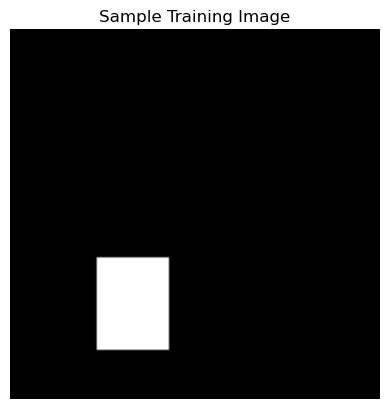

In [2]:
plt.imshow(X[0])
plt.title("Sample Training Image")
plt.axis("off")
plt.show()

In [5]:
# ---
# 2. Train / Test Split
# ---

split = int(len(X)*0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
# ---
# 3. Build a YOLO-like CNN Model
# ---

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(IMAGE_SIZE,IMAGE_SIZE,3)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(5, activation='sigmoid')
])

# Output: bounding box + class
tf.keras.layers.Dense(5, activation='sigmoid')

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,989 (6.22 MB)

 Trainable params: 1,629,989 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 4. Train Model
history = model.fit(
    X_train,    # 1
    y_train,    # 2
    validation_split=0.2,    # 3
    epochs=10,    # 4
    batch_size=8    # 5
)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0225 - val_loss: 0.0057
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0021 - val_loss: 0.0024
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9.6867e-04 - val_loss: 0.0015
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 7.9607e-04 - val_loss: 0.0016
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 5.4048e-04 - val_loss: 0.0014
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.4702e-04 - val_loss: 0.0016
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 4.1334e-04 - val_loss: 0.0015
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 3.2064e-04 - val_loss: 0.0014


In [9]:
# ---
# 5. Evaluate Model
# ---

loss = model.evaluate(X_test, y_test)

print("Test Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0016 
Test Loss: 0.0016102537047117949


In [10]:
# 6. IoU (Intersection over Union)

def IoU(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    x1_min = x1 - w1/2
    x1_max = x1 + w1/2
    y1_min = y1 - h1/2
    y1_max = y1 + h1/2

    x2_min = x2 - w2/2
    x2_max = x2 + w2/2
    y2_min = y2 - h2/2
    y2_max = y2 + h2/2

    inter_xmin = max(x1_min, x2_min)
    inter_ymin = max(y1_min, y2_min)
    inter_xmax = min(x1_max, x2_max)
    inter_ymax = min(y1_max, y2_max)

    inter_area = max(0, inter_xmax - inter_xmin) * max(0, inter_ymax - inter_ymin)

    area1 = w1 * h1
    area2 = w2 * h2

    union = area1 + area2 - inter_area

    return inter_area / union

In [12]:
# ---
# 7. Test Predictions
# ---

preds = model.predict(X_test[:5])

for i in range(5):

    pred_box = preds[i][:4]
    true_box = y_test[i][:4]

    iou = IoU(pred_box, true_box)

    print("\nExample", i+1)
    print("True Box:", true_box)
    print("Pred Box:", pred_box)
    print("IOU:", iou)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Example 1
True Box: [0.65625   0.5390625 0.15625   0.171875 ]
Pred Box: [0.6362077  0.54560065 0.21289799 0.24541709]
IOU: 0.5139920477310109

Example 2
True Box: [0.66015625 0.5625     0.2734375  0.28125   ]
Pred Box: [0.65258855 0.5755532  0.19260015 0.21083933]
IOU: 0.5280286233527353

Example 3
True Box: [0.3203125  0.41015625 0.296875   0.3046875 ]
Pred Box: [0.26667237 0.39538002 0.23422651 0.22604114]
IOU: 0.5015843990939088

Example 4
True Box: [0.66015625 0.29296875 0.2265625  0.2421875 ]
Pred Box: [0.6652058  0.31044763 0.157857   0.25872225]
IOU: 0.6240267816190366

Example 5
True Box: [0.62109375 0.51171875 0.1796875  0.1640625 ]
Pred Box: [0.6043289  0.5138552  0.21946955 0.2313049 ]
IOU: 0.5807217457158457
